# CTransformer usando PyTorch Lightning
## Objetivos

- Importar una base de datos de audio
- Definir un modulo Dataset
- Definir un modelo convolucional - transformer para clasificacion de audio

## Instalar e importar bibliotecas


In [20]:
import os
import pandas as pd
import time
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
import torchmetrics
from torchinfo import summary

import torchaudio
import soundfile as sf
from pydub import AudioSegment
from pydub.playback import play

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import TQDMProgressBar, RichProgressBar

# Local imports
from settings import DATA_DIR, LOGS_DIR

# Configurar semillas para reproducibilidad del split de datos
torch.manual_seed(47)
torch.cuda.manual_seed_all(47)
np.random.seed(47)
torch.version.__version__

'2.10.0+cu128'

In [21]:
from settings.optimizations import *

In [22]:
import time


class SimpleEpochProgressCallback(pl.Callback):
    """Lightweight callback to show epoch progress without progress bar overhead."""

    def __init__(self):
        super().__init__()
        self.epoch_start_time = None

    def on_train_start(self, trainer, pl_module):
        """Print training configuration at the start."""
        train_dataloader = trainer.train_dataloader

        # Get batch size and number of batches
        if hasattr(train_dataloader, "batch_size"):
            batch_size = train_dataloader.batch_size
        elif hasattr(train_dataloader, "loaders") and hasattr(
            train_dataloader.loaders, "batch_size"
        ):
            batch_size = train_dataloader.loaders.batch_size
        else:
            batch_size = getattr(train_dataloader, "batch_size", "N/A")

        num_batches = len(train_dataloader)

        print(
            f"\nTraining Configuration: Batch Size={batch_size}, Steps per Epoch={num_batches}\n"
        )

    def on_train_epoch_start(self, trainer, pl_module):
        """Record the start time of the epoch."""
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        """Print single-line summary at the end of each training epoch."""
        current_epoch = trainer.current_epoch + 1
        max_epochs = trainer.max_epochs

        # Calculate epoch duration
        epoch_time = time.time() - self.epoch_start_time if self.epoch_start_time else 0

        # Get metrics from logged values
        train_loss = trainer.callback_metrics.get("train_loss", None)
        val_loss = trainer.callback_metrics.get("val_loss", None)
        val_acc = trainer.callback_metrics.get("val_acc", None)

        # Build single-line output
        parts = [f"Epoch {current_epoch}/{max_epochs}"]

        if train_loss is not None:
            parts.append(f"Train Loss: {train_loss:.4f}")
        if val_loss is not None:
            parts.append(f"Val Loss: {val_loss:.4f}")
        if val_acc is not None:
            parts.append(f"Val Acc: {val_acc:.4f}")

        parts.append(f"Time: {epoch_time:.2f}s")

        print(" | ".join(parts))

## Definición de hiperparámetros de la red

In [23]:
BATCH_SIZE = 32
NUM_EPOCHS = 200
LEARNING_RATE = 0.0001
NUM_WORKERS = 4
CLASES = 10

ANNOTATIONS_FILE = f"{DATA_DIR}/UrbanSound8K/metadata/UrbanSound8K.csv"
AUDIO_DIR = f"{DATA_DIR}/UrbanSound8K/audio/"
SAMPLE_RATE = 8000  # frecuencia de muestreo deseada
MAX_LEN_SEC = 4  # longitud maxima del audio en segundos

## Preparación de la base de datos: UrbanSound8k

### Descargar UrbanSound8k y descomprimir en directorio './data'

https://www.kaggle.com/datasets/chrisfilo/urbansound8k?resource=download

### Informacion general del dataset en:

https://urbansounddataset.weebly.com/urbansound8k.html

### Visualizacion de una muestra:

In [24]:
from utils.data_downloader import download_and_extract

download_and_extract(
    url="https://zenodo.org/record/1203745/files/UrbanSound8K.tar.gz",
    name="UrbanSound8K",
)

El dataset UrbanSound8K ya existe. Omitiendo descarga.


In [25]:
all_csv = pd.read_csv(ANNOTATIONS_FILE)
all_csv.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


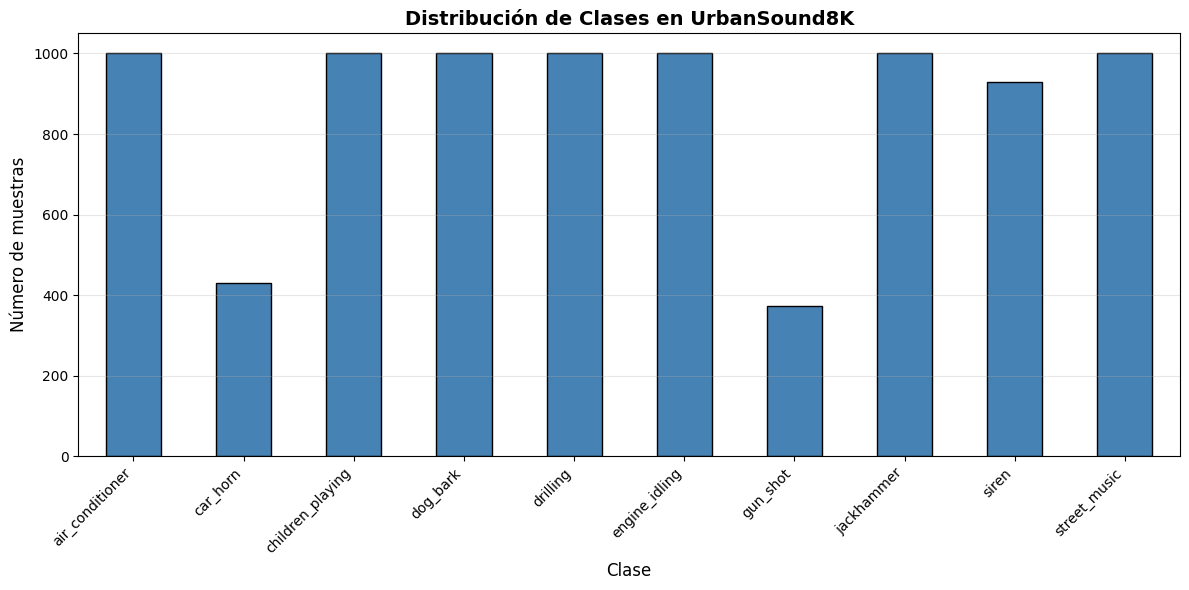


Conteo por clase:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

Total de muestras: 8732


In [26]:
# Distribución de las clases
class_counts = all_csv["class"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
class_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribución de Clases en UrbanSound8K", fontsize=14, fontweight="bold")
plt.xlabel("Clase", fontsize=12)
plt.ylabel("Número de muestras", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConteo por clase:")
print(class_counts)
print(f"\nTotal de muestras: {len(all_csv)}")

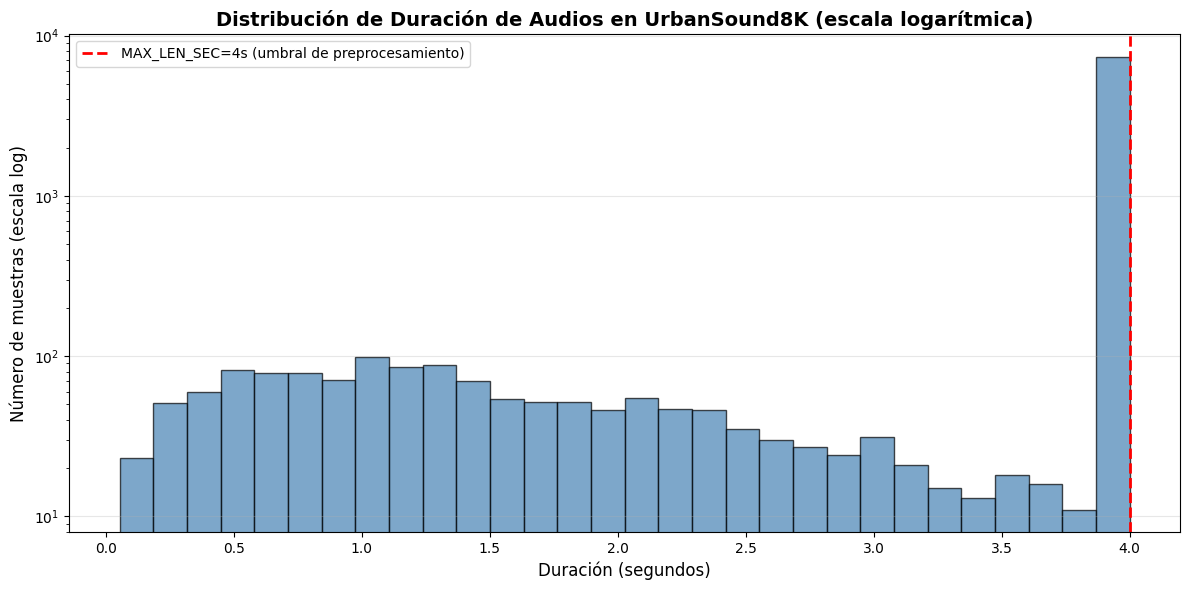


ESTADÍSTICAS DE DURACIÓN DE AUDIOS
Media:              3.608s
Mediana:            4.000s
Desviación estándar: 0.974s
Mínimo:             0.055s
Máximo:             4.000s

Muestras ≤ 4s: 8519 (97.6%)
Muestras > 4s: 213 (2.4%) - serán truncadas

Total de muestras: 8732


In [27]:
# Calcular la duración de cada audio en segundos
all_csv["duration"] = all_csv["end"] - all_csv["start"]

# Crear histograma de la distribución de duraciones
plt.figure(figsize=(12, 6))
plt.hist(all_csv["duration"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(
    MAX_LEN_SEC,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"MAX_LEN_SEC={MAX_LEN_SEC}s (umbral de preprocesamiento)",
)
plt.yscale("log")  # Escala logarítmica en el eje Y
plt.title(
    "Distribución de Duración de Audios en UrbanSound8K (escala logarítmica)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Duración (segundos)", fontsize=12)
plt.ylabel("Número de muestras (escala log)", fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Imprimir estadísticas descriptivas
print("\n" + "=" * 60)
print("ESTADÍSTICAS DE DURACIÓN DE AUDIOS")
print("=" * 60)
print(f"Media:              {all_csv['duration'].mean():.3f}s")
print(f"Mediana:            {all_csv['duration'].median():.3f}s")
print(f"Desviación estándar: {all_csv['duration'].std():.3f}s")
print(f"Mínimo:             {all_csv['duration'].min():.3f}s")
print(f"Máximo:             {all_csv['duration'].max():.3f}s")
print("=" * 60)

# Analizar muestras respecto al umbral MAX_LEN_SEC
over_threshold = (all_csv["duration"] > MAX_LEN_SEC).sum()
under_threshold = (all_csv["duration"] <= MAX_LEN_SEC).sum()
print(
    f"\nMuestras ≤ {MAX_LEN_SEC}s: {under_threshold} ({under_threshold/len(all_csv)*100:.1f}%)"
)
print(
    f"Muestras > {MAX_LEN_SEC}s: {over_threshold} ({over_threshold/len(all_csv)*100:.1f}%) - serán truncadas"
)
print(f"\nTotal de muestras: {len(all_csv)}")

In [28]:
all_csv

,slice_file_name,fsID,start,end,salience,fold,classID,class,duration
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark,0.317551
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing,4.000000
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing,4.000000
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing,4.000000
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing,4.000000
...,...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn,4.000000
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn,2.142545
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn,3.505983
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn,2.532098


In [29]:
fold = f"fold{all_csv.iloc[0, 5]}"
path = os.path.join(AUDIO_DIR, fold, all_csv.iloc[0, 0])
audio = AudioSegment.from_file(path)
# play(audio)

torch.Size([2, 14004]) 44100


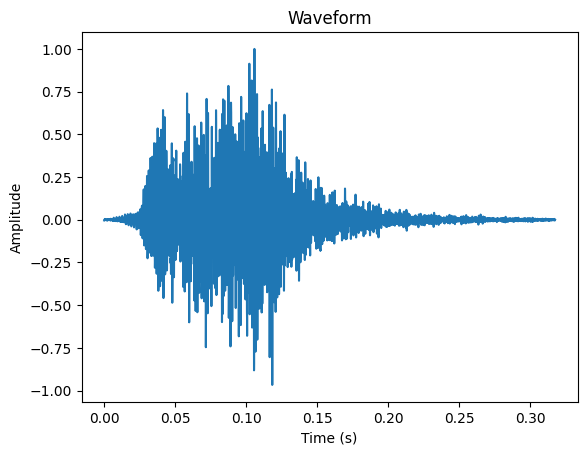

In [30]:
# Load the audio file
audio_np, sample_rate = sf.read(path, always_2d=True)  # shape: (num_samples, channels)
waveform = torch.from_numpy(audio_np.T).float()  # shape: (channels, num_samples)
print(waveform.shape, sample_rate)
# Create a time axis
time_axis = torch.arange(0, waveform.shape[-1]) / sample_rate
# Plot the waveform
plt.plot(time_axis, waveform[0])
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform")
plt.show()

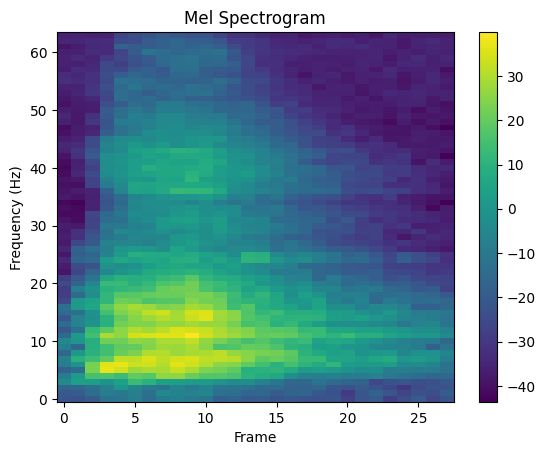

In [39]:
# Definimos el computo del espectrograma de mel como una transformacion
# https://docs.pytorch.org/audio/main/transforms.html

mel_spectrogram = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,  # numero de puntos fft para transformar de tiempo a frecuencia
    hop_length=512,
    n_mels=64,
)
# aplicamos el espectrograma de mel
mel_spectrogram_ = mel_spectrogram(waveform)

# Convertimos a escala logaritmica (dB) para facilitar la visualizacion de detalles en todo el rango del espectrograma
# Practica estandar en analisis de audio para destacar los picos y valles
mel_spectrogram_db = torchaudio.transforms.AmplitudeToDB()(mel_spectrogram_)

# Plot mel spectrogram
fig, axs = plt.subplots(1, 1)
axs.set_title("Mel Spectrogram")
axs.set_ylabel("Frequency (Hz)")
axs.set_xlabel("Frame")
im = axs.imshow(mel_spectrogram_db[0], origin="lower", aspect="auto")
fig.colorbar(im, ax=axs)
plt.show()

In [32]:
def calculate_mel_spec_dims(max_len_sec, sample_rate, hop_length, n_mels):
    """
    Calculate expected mel spectrogram dimensions based on audio parameters.

    Formula explanation:
    - Audio samples: max_len_sec * sample_rate
    - Time frames: audio_samples // hop_length + 1
      (The +1 accounts for center=True padding in MelSpectrogram)

    Returns:
        tuple: (channels, n_mels, time_frames) - e.g., (1, 64, 63)
    """
    num_samples = max_len_sec * sample_rate
    time_frames = num_samples // hop_length + 1
    return (1, n_mels, time_frames)


# Calculate expected input dimensions automatically
EXPECTED_INPUT_DIM = calculate_mel_spec_dims(
    MAX_LEN_SEC,
    SAMPLE_RATE,
    mel_spectrogram.hop_length,  # 512
    mel_spectrogram.n_mels,  # 64
)
print(f"Expected mel spectrogram shape: {EXPECTED_INPUT_DIM}")
print(f"  - Channels: {EXPECTED_INPUT_DIM[0]}")
print(f"  - Mel bins: {EXPECTED_INPUT_DIM[1]}")
print(f"  - Time frames: {EXPECTED_INPUT_DIM[2]}")

Expected mel spectrogram shape: (1, 64, 63)
  - Channels: 1
  - Mel bins: 64
  - Time frames: 63


### Relación entre MAX_LEN_SEC y dimensiones del mel spectrogram

La longitud de la secuencia temporal (frames) del mel spectrogram se calcula automáticamente:

**Fórmula:** `time_frames = (MAX_LEN_SEC × SAMPLE_RATE) ÷ hop_length + 1`

**Ejemplo con parámetros actuales:**
- MAX_LEN_SEC = 4 segundos
- SAMPLE_RATE = 8000 Hz
- hop_length = 512
- time_frames = (4 × 8000) ÷ 512 + 1 = 63 frames

**Nota:** El +1 es por el padding automático (`center=True`) en MelSpectrogram.

Si cambias MAX_LEN_SEC, las dimensiones se actualizan automáticamente al re-ejecutar las celdas.

In [33]:
waveform.shape

torch.Size([2, 14004])

In [34]:
mel_spectrogram_db.shape

torch.Size([2, 64, 28])

### Definicion de clase Dataset para UrbanSound8k

In [35]:
class UrbanSoundDataset(Dataset):
    def __init__(
        self,
        annotations_file,
        audio_dir,
        transformation,
        target_sample_rate,
        max_len,
        training=True,
    ):
        self.annotations = pd.read_csv(annotations_file)
        self.audio_dir = audio_dir
        self.transformation = transformation
        self.amplitude_to_db = T.AmplitudeToDB()  # Conversión a escala logarítmica (dB)
        self.target_sample_rate = target_sample_rate
        self.max_len = max_len
        self.training = training  # Para activar/desactivar data augmentation

        # SpecAugment: solo para entrenamiento
        if self.training:
            self.freq_mask = T.FrequencyMasking(
                freq_mask_param=8
            )  # Enmascara hasta 8 mel bins
            self.time_mask = T.TimeMasking(
                time_mask_param=15
            )  # Enmascara hasta 15 frames

    def _get_audio_sample_path(self, index):
        fold = f"fold{self.annotations.iloc[index, 5]}"
        path = os.path.join(self.audio_dir, fold, self.annotations.iloc[index, 0])
        return path

    def _resample_if_necessary(self, signal, sr):
        if sr != self.target_sample_rate:
            resampler = T.Resample(sr, self.target_sample_rate)
            signal = resampler(signal)
        return signal

    def _mix_down_if_necessary(
        self, signal
    ):  # reducimos dos canales de audio  (stereo) a monocanal
        if signal.shape[0] > 1:
            signal = torch.mean(signal, dim=0, keepdim=True)
        return signal

    # Limitamos o rellenamos el audio a 4sec porque cada batch debe tener muestras con igual longitud
    def _cut_if_necessary(self, signal):
        if signal.shape[1] > self.max_len * self.target_sample_rate:
            signal = signal[:, : self.max_len * self.target_sample_rate]
        return signal

    def _right_pad_if_necessary(self, signal):
        length_signal = signal.shape[1]
        if length_signal < self.max_len * self.target_sample_rate:
            num_missing_samples = self.max_len * self.target_sample_rate - length_signal
            last_dim_padding = (0, num_missing_samples)
            signal = F.pad(signal, last_dim_padding)
        return signal

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):

        audio_sample_path = self._get_audio_sample_path(index)
        audio_np, sr = sf.read(audio_sample_path, always_2d=True)
        signal = torch.from_numpy(audio_np.T).float()
        label = self.annotations.iloc[index, 6]

        # Preprocesamiento de la señal
        signal = self._resample_if_necessary(signal, sr)
        signal = self._mix_down_if_necessary(signal)
        signal = self._cut_if_necessary(signal)
        signal = self._right_pad_if_necessary(signal)

        # Calculamos el mel spectrogram
        signal = self.transformation(signal)

        # Convertir a escala dB (logarítmica)
        signal = self.amplitude_to_db(signal)

        # SpecAugment: aplicar frequency y time masking (solo durante entrenamiento)
        if self.training:
            # Frequency masking con 50% de probabilidad
            if torch.rand(1).item() > 0.5:
                signal = self.freq_mask(signal)

            # Time masking con 50% de probabilidad
            if torch.rand(1).item() > 0.5:
                signal = self.time_mask(signal)

        # Normalización (media=0, std=1) - siempre al final
        mean = signal.mean()
        std = signal.std()
        signal = (signal - mean) / (std + 1e-8)  # epsilon para estabilidad numérica

        return signal, label  # mel spec normalizado y aumentado, clase

In [ ]:
# Inicializamos la clase para el dataset
us8k_dataset = UrbanSoundDataset(
    ANNOTATIONS_FILE, AUDIO_DIR, mel_spectrogram, SAMPLE_RATE, MAX_LEN_SEC
)

# Inicializamos dataloader
us8k_dataloader = DataLoader(us8k_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [37]:
print("Número de muestras en la base:", len(us8k_dataset))

Número de muestras en la base: 8732


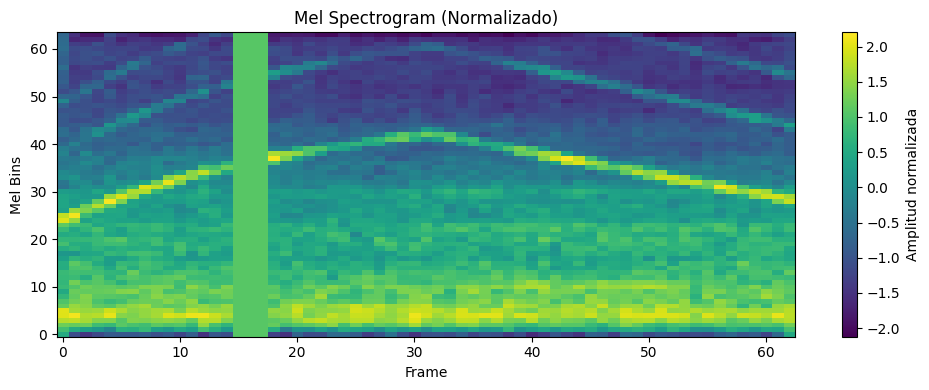

In [44]:
for signal, label in us8k_dataloader:  # signal is a batch
    break

# Los datos ya están en dB y normalizados desde el dataloader
# Plot mel spectrogram
fig, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.set_title("Mel Spectrogram (Normalizado)")
axs.set_ylabel("Mel Bins")
axs.set_xlabel("Frame")
im = axs.imshow(signal[0, 0], origin="lower", aspect="auto", cmap="viridis")
fig.colorbar(im, ax=axs, label="Amplitud normalizada")
plt.tight_layout()
plt.show()

In [45]:
# Dimensión de cada muestra
print(
    "Dimensión de entrada:", signal.shape
)  # (batch_size, channels_in, mel_bins, temp_frames)

Dimensión de entrada: torch.Size([32, 1, 64, 63])


In [46]:
# Validar que las dimensiones de los datos coincidan con las esperadas
actual_dims = signal.shape[1:]  # (channels, mel_bins, time_frames)

if actual_dims == EXPECTED_INPUT_DIM:
    print(f"✓ Validación exitosa: Las dimensiones coinciden con las esperadas")
    print(f"  Dimensiones: {actual_dims}")
else:
    print(f"✗ ADVERTENCIA: Discrepancia en dimensiones detectada!")
    print(f"  Esperadas: {EXPECTED_INPUT_DIM}")
    print(f"  Reales:    {actual_dims}")
    print(f"  → Revisa los parámetros MAX_LEN_SEC, SAMPLE_RATE, n_fft, hop_length")

✓ Validación exitosa: Las dimensiones coinciden con las esperadas
  Dimensiones: torch.Size([1, 64, 63])


### Definición de UrbanSound8k DataModule para Lightning

In [47]:
class UrbanSound8KDataModule(pl.LightningDataModule):
    def __init__(
        self,
        csv_file,
        root_dir,
        mel_transf,
        target_sr,
        max_len_s,
        batch_size,
        num_workers,
    ):
        super().__init__()
        self.csv_file = csv_file
        self.root_dir = root_dir
        self.mel_transf = mel_transf
        self.target_sr = target_sr
        self.max_len_s = max_len_s
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        # Crear dataset temporal para obtener los índices del split
        temp_dataset = UrbanSoundDataset(
            self.csv_file,
            self.root_dir,
            self.mel_transf,
            self.target_sr,
            self.max_len_s,
            training=False,
        )

        # Calcular tamaños del split
        train_size = int(0.8 * len(temp_dataset))
        val_test_size = len(temp_dataset) - train_size
        val_size = val_test_size // 2
        test_size = val_test_size - val_size

        # Split con generador fijo para reproducibilidad
        generator = torch.Generator().manual_seed(47)
        train_indices, val_indices, test_indices = random_split(
            range(len(temp_dataset)),
            [train_size, val_size, test_size],
            generator=generator,
        )

        # Crear datasets separados con augmentation SOLO para train
        train_full = UrbanSoundDataset(
            self.csv_file,
            self.root_dir,
            self.mel_transf,
            self.target_sr,
            self.max_len_s,
            training=True,  # Con SpecAugment
        )
        val_full = UrbanSoundDataset(
            self.csv_file,
            self.root_dir,
            self.mel_transf,
            self.target_sr,
            self.max_len_s,
            training=False,  # Sin SpecAugment
        )
        test_full = UrbanSoundDataset(
            self.csv_file,
            self.root_dir,
            self.mel_transf,
            self.target_sr,
            self.max_len_s,
            training=False,  # Sin SpecAugment
        )

        # Aplicar los índices del split usando Subset
        from torch.utils.data import Subset

        self.train_dataset = Subset(train_full, train_indices.indices)
        self.val_dataset = Subset(val_full, val_indices.indices)
        self.test_dataset = Subset(test_full, test_indices.indices)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

In [48]:
# Inicializamos el DataModule Lightning
data_module = UrbanSound8KDataModule(
    csv_file=ANNOTATIONS_FILE,
    root_dir=AUDIO_DIR,
    mel_transf=mel_spectrogram,
    target_sr=SAMPLE_RATE,
    max_len_s=MAX_LEN_SEC,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

## Definición de la arquitectura de la CTransformer

TODOs: 
- Entender la entrada y salida del [Transformer Encoder](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html)
- Implementar una capa custom de embedding tradicional y posicional.
- Implementar la clase CTransformer que contenga las capas convolucionales y el transformer encoder.
- Describir la arquitectura.

In [51]:
# Capa personalizada para hacer visible el reshape en torchinfo
class Reshape(nn.Module):
    def __init__(self, target_shape):
        super(Reshape, self).__init__()
        self.target_shape = target_shape

    def forward(self, x):
        batch_size = x.size(0)
        return x.view(batch_size, *self.target_shape)


class CTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super(CTransformer, self).__init__()

        # Agrupar todas las capas convolucionales en un Sequential
        self.conv_layers = nn.Sequential(
            nn.Conv2d(
                in_channels=input_dim[0], out_channels=16, kernel_size=(3, 3), padding=1
            ),
            nn.BatchNorm2d(16),  # Normalización después de Conv2d
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=(2, 1)
            ),  # Pool solo en frecuencia (height), preserva tiempo (width)
            nn.Dropout2d(p=0.1),  # Regularización espacial
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),  # Normalización después de Conv2d
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=(2, 1)
            ),  # Pool solo en frecuencia (height), preserva tiempo (width)
            nn.Dropout2d(p=0.25),  # Regularización espacial
        )

        # Inferir dimensiones automáticamente con un forward pass dummy
        with torch.no_grad():
            dummy_input = torch.zeros(
                1, *input_dim
            )  # Shape: (1, channels_in, mel_bins, frames)
            dummy_output = self.conv_layers(dummy_input)
            # Después de conv_layers => Shape: (1, 32, height_reduced, width_preserved)
            # Ejemplo con input (1, 1, 64, 63): dummy_output shape = (1, 32, 16, 63)

            # Usar width como timesteps (frames temporales del mel spectrogram)
            # width representa los frames temporales del audio (ahora se preservan todos)
            self.seq_length = dummy_output.shape[3]  # width (frames temporales) => 63
            self.rnn_input_dim = (
                dummy_output.shape[1] * dummy_output.shape[2]
            )  # channels * height => 32*16 = 512

        # Crear Reshape con dimensiones inferidas
        # Después de Reshape => Shape: (batch, seq_length, rnn_input_dim)
        # Ejemplo: (batch, 63, 512) - cada timestep tiene 512 features
        self.reshape = Reshape((self.seq_length, self.rnn_input_dim))

        # TODO: Cambiar la lstm por un transformer encoder
        # LSTM bidireccional con 2 capas y dropout entre capas
        # Input: (batch, seq_length, rnn_input_dim) => (batch, 63, 512)
        # Output: (batch, seq_length, hidden_size*2) => (batch, 63, 256) porque bidirectional=True
        self.lstm = nn.LSTM(
            input_size=self.rnn_input_dim,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.25,  # Dropout entre capas del LSTM (solo funciona con num_layers > 1)
        )

        # Dropout antes de la capa fully connected
        self.dropout = nn.Dropout(p=0.25)

        # Segunda capa lineal: añadimos una capa oculta intermedia
        # Input: (batch, 256) - último timestep del LSTM
        # Output: (batch, 128) - capa oculta intermedia
        self.fc1 = nn.Linear(128 * 2, 128)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(p=0.25)

        # Capa de salida para clasificación
        # Input: (batch, 128) - capa oculta
        # Output: (batch, num_classes) => (batch, 10)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input: (batch, 1, 64, 63) - mel spectrogram

        # Aplicar capas convolucionales (con BatchNorm y Dropout)
        x = self.conv_layers(x)
        # Shape después: (batch, 32, 16, 63) - preservamos los 63 frames temporales
        # 16 = 64 mel bins reducidos por pooling (2,1) dos veces: 64 -> 32 -> 16
        # 63 = frames temporales preservados (no reducidos por pooling)

        # Re-estructurar el tensor de salida usando la capa Reshape
        x = self.reshape(x)
        # Shape después: (batch, 63, 512)
        # Ahora tenemos 63 timesteps, cada uno con 512 features (32 canales * 16 bins frecuencia)

        # TODO: Reemplazar LSTM por Transformer Encoder
        # Aplicamos LSTM (con dropout interno)
        x, _ = self.lstm(x)
        # Shape después: (batch, 63, 256)
        # 256 = 128*2 por el LSTM bidireccional

        # Tomamos el ultimo time step de la secuencia del estado oculto
        # El ultimo time step de la secuencia resume la representacion de toda la secuencia
        x = x[:, -1, :]
        # Shape después: (batch, 256)

        # Average pooling a lo largo de la dimension temporal (alternativa comentada)
        # x = torch.mean(x, dim=1)
        # Shape después: (batch, 256)

        # Aplicar dropout antes de la primera capa fully connected
        x = self.dropout(x)
        # Shape después: (batch, 256) - con dropout aplicado

        # Primera capa fully connected con activación ReLU
        x = self.fc1(x)
        # Shape después: (batch, 128)
        x = self.relu(x)

        # Aplicar segundo dropout
        x = self.dropout2(x)
        # Shape después: (batch, 128) - con dropout aplicado

        # Segunda capa fully connected (capa de salida)
        x = self.fc2(x)
        # Shape después: (batch, 10) - logits para 10 clases

        return x  # Devuelve logits (NO probabilidades)

## Definición del Módulo Lightning

In [50]:
class Lightning_CTransformer(pl.LightningModule):
    def __init__(self, input_dim, num_classes, lr):
        super().__init__()
        self.learning_rate = lr
        self.classes = num_classes
        self.model = CTransformer(input_dim=input_dim, num_classes=self.classes)

        # Guardar hiperparametros en directorio de logs
        # Ignora los pesos del modelo
        self.save_hyperparameters(ignore=["model"])

        # Definición de métricas para cada grupo de datos
        self.train_acc = torchmetrics.Accuracy(
            num_classes=self.classes, task="multiclass"
        )
        self.val_acc = torchmetrics.Accuracy(
            num_classes=self.classes, task="multiclass"
        )
        self.test_acc = torchmetrics.Accuracy(
            num_classes=self.classes, task="multiclass"
        )

    def forward(self, x):
        return self.model(x)

    # Pasos del proceso forward comunes entre train, val, test
    def _shared_step(self, batch):
        features, true_labels = batch
        logits = self(features)
        loss = torch.nn.functional.cross_entropy(
            logits, true_labels
        )  # cross entropy loss recibe logits y labels como entrada. No recibe probabilidades!
        predicted_labels = torch.argmax(logits, dim=1)

        return loss, true_labels, predicted_labels

    def training_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("train_loss", loss)
        self.train_acc(predicted_labels, true_labels)
        self.log("train_acc", self.train_acc, on_epoch=True, on_step=False)
        self.model.train()

        return loss

    def validation_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.log("val_loss", loss)
        self.val_acc(predicted_labels, true_labels)
        self.log("val_acc", self.val_acc, on_epoch=True, on_step=False, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, true_labels, predicted_labels = self._shared_step(batch)
        self.test_acc(predicted_labels, true_labels)
        self.log("test_acc", self.test_acc, on_epoch=True, on_step=False)

    def configure_optimizers(self):
        # Optimizer con weight decay para L2 regularization
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.learning_rate,
            weight_decay=1e-4,  # L2 regularization
        )

        # Learning rate scheduler: reduce LR cuando val_loss se estanca
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",  # Minimizar val_loss
            factor=0.5,  # Reducir LR a la mitad
            patience=5,  # Esperar 5 epochs sin mejora
            # verbose=True,         # Imprimir cuando cambie el LR deprecated!
            min_lr=1e-6,  # LR mínimo
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",  # Métrica a monitorear
                "interval": "epoch",  # Evaluar cada epoch
                "frequency": 1,  # Evaluar cada 1 epoch
            },
        }

## Entrenamiento del modelo

In [52]:
# Inicialización del modulo lightning

lightning_model = Lightning_CTransformer(
    input_dim=EXPECTED_INPUT_DIM, num_classes=CLASES, lr=LEARNING_RATE
)

callback_check = ModelCheckpoint(
    save_top_k=1, save_last=True, mode="min", monitor="val_loss"
)  # guardamos el mejor modelo monitoreado en la acc de validación. Por qué no la de entrenamiento?

callback_early_stop = EarlyStopping(
    monitor="val_loss", patience=20, mode="min", verbose=True
)

callback_tqdm = RichProgressBar(leave=True)  # not used

# Add epoch progress callback to callbacks list
epoch_progress = SimpleEpochProgressCallback()

logger = CSVLogger(save_dir=LOGS_DIR, name="ctrasformer-urbansound8k")

In [ ]:
# Visualizar arquitectura del modelo
print("Input size:", (BATCH_SIZE, *signal.shape[1:]))
print("Valores inferidos automáticamente:")
print(f"  - seq_length: {lightning_model.model.seq_length}")
print(f"  - rnn_input_dim: {lightning_model.model.rnn_input_dim}")
print()
summary(lightning_model.model, input_size=(BATCH_SIZE, *signal.shape[1:]))

### Configuración de Checkpoint Recovery
Si tu entrenamiento se interrumpe, puedes recuperarlo desde el último checkpoint guardado. PyTorch Lightning guarda automáticamente checkpoints en la carpeta `logs/` (o la que hayas configurado previamente).
El entrenamiento soporta **3 modos** :

#### Modo 1: Entrenar desde cero (por defecto)
```python
CHECKPOINT_PATH = None
LOAD_WEIGHTS_ONLY = False
```

#### Modo 2: Continuar entrenamiento desde checkpoint (RECOMENDADO)
Mantiene el estado completo: epoch actual, optimizer, scheduler, etc.
```python
CHECKPOINT_PATH = "logs/crnn-2-urbansound8k/version_26/checkpoints/epoch=62-step=13797.ckpt"
LOAD_WEIGHTS_ONLY = False
```

#### Modo 3: Cargar solo pesos del modelo
Útil para transfer learning o fine-tuning. Reinicia epoch, optimizer y scheduler.
```python
CHECKPOINT_PATH = "logs/crnn-2-urbansound8k/version_26/checkpoints/epoch=62-step=13797.ckpt"
LOAD_WEIGHTS_ONLY = True
```



In [ ]:
# ========== TRAINING CONFIGURATION ==========
# Configure checkpoint recovery here

CHECKPOINT_PATH = None  # Set to checkpoint path (e.g., "logs/.../epoch=62.ckpt") or None for training from scratch
# CHECKPOINT_PATH = "logs/crnn-2-urbansound8k/version_26/checkpoints/epoch=62-step=13797.ckpt"
LOAD_WEIGHTS_ONLY = False  # True = load weights but restart training (epoch=0, reset optimizer/scheduler, callback state)

# Examples:
# CHECKPOINT_PATH = None                                  # Train from scratch
# CHECKPOINT_PATH = "logs/.../epoch=62.ckpt"              # Resume training (LOAD_WEIGHTS_ONLY=False)
# CHECKPOINT_PATH = "logs/.../epoch=62.ckpt" + LOAD_WEIGHTS_ONLY=True  # Load weights, restart training

# ============================================

trainer = pl.Trainer(
    max_epochs=NUM_EPOCHS,
    callbacks=[callback_check, callback_early_stop, epoch_progress],
    accelerator="auto",
    devices="auto",
    logger=logger,
    deterministic=False,
    log_every_n_steps=10,
    enable_progress_bar=ENABLE_PROGRESS_BAR,
)

if CHECKPOINT_PATH is None:
    # Mode: Train from scratch
    print("=" * 60)
    print("Training mode: From scratch")
    print("=" * 60)
    start_time = time.time()
    trainer.fit(model=lightning_model, datamodule=data_module)

elif not LOAD_WEIGHTS_ONLY:
    # Mode: Resume from checkpoint (continues epoch, optimizer, scheduler state, ...
    # checkpoint states such as early stop are restored (e.g. patience) to their original values even if changed)

    print("=" * 60)
    print("Training mode: Resume from checkpoint")
    print(f"Checkpoint: {CHECKPOINT_PATH}")
    print("=" * 60)
    start_time = time.time()
    trainer.fit(
        model=lightning_model, datamodule=data_module, ckpt_path=CHECKPOINT_PATH
    )

else:
    # Mode: Load weights only (start from epoch 0 with pretrained weights)
    print("=" * 60)
    print("Training mode: Load pretrained weights")
    print(f"Checkpoint: {CHECKPOINT_PATH}")
    print("=" * 60)

    # Load model from checkpoint
    lightning_model = Lightning_CRNN.load_from_checkpoint(
        CHECKPOINT_PATH,
        input_dim=EXPECTED_INPUT_DIM,
        num_classes=CLASES,
        lr=LEARNING_RATE,
    )

    # Train from epoch 0 with pretrained weights
    start_time = time.time()
    trainer.fit(model=lightning_model, datamodule=data_module)

runtime = (time.time() - start_time) / 60
print(f"\nTiempo de entrenamiento en minutos: {runtime:.2f}")

## Graficamos las curvas de aprendizaje del modelo

In [ ]:
# Determine which metrics.csv to read based on checkpoint usage
if CHECKPOINT_PATH is not None and LOAD_WEIGHTS_ONLY is False:
    # Extract the log directory from the checkpoint path
    # Path format: "logs/crnn-2-urbansound8k/version_X/checkpoints/epoch=Y.ckpt"
    checkpoint_log_dir = os.path.dirname(os.path.dirname(CHECKPOINT_PATH))
    metrics_path = f"{checkpoint_log_dir}/metrics.csv"
    print(f"Loading metrics from checkpoint's original training run:")
    print(f"  {metrics_path}")
else:
    # Use current training run
    metrics_path = f"{trainer.logger.log_dir}/metrics.csv"
    print(f"Loading metrics from current training run:")
    print(f"  {metrics_path}")

metrics = pd.read_csv(metrics_path)

aggreg_metrics = []
agg_col = "epoch"
for i, dfg in metrics.groupby(agg_col):
    agg = dict(dfg.mean())
    agg[agg_col] = i
    aggreg_metrics.append(agg)

df_metrics = pd.DataFrame(aggreg_metrics)
df_metrics[["train_loss", "val_loss"]].plot(
    grid=True, legend=True, xlabel="Epoch", ylabel="Loss"
)
df_metrics[["train_acc", "val_acc"]].plot(
    grid=True, legend=True, xlabel="Epoch", ylabel="ACC"
)

plt.show()

## Evaluamos el mejor modelo en el grupo de test

In [ ]:
trainer.test(
    model=lightning_model, datamodule=data_module, ckpt_path="best"
)  # cargamos el mejor checkpoint del modelo